In [1]:
# Fairness Audit
# Goal: Formally measure bias in the baseline model
# Metrics: Demographic parity, equalized odds, calibration parity

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate

print("Libraries loaded")

Libraries loaded


In [2]:
# Load data and retrain model
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()
sensitive_test = pd.read_csv("../data/processed/sensitive_test.csv")

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model ready")

Model ready


In [3]:
# Fairness metrics by sex using FairLearn
metrics = {
    'accuracy': lambda y_true, y_pred: (y_true == y_pred).mean(),
    'selection_rate': selection_rate,
    'false_positive_rate': false_positive_rate,
    'false_negative_rate': false_negative_rate
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test['sex']
)

print("Overall metrics:")
print(metric_frame.overall)
print("\nMetrics by sex (0=Female, 1=Male):")
print(metric_frame.by_group)

Overall metrics:
accuracy               0.816667
selection_rate         0.233333
false_positive_rate    0.073171
false_negative_rate    0.421053
dtype: float64

Metrics by sex (0=Female, 1=Male):
     accuracy  selection_rate  false_positive_rate  false_negative_rate
sex                                                                    
0    0.789474        0.263158             0.083333             0.428571
1    0.829268        0.219512             0.068966             0.416667


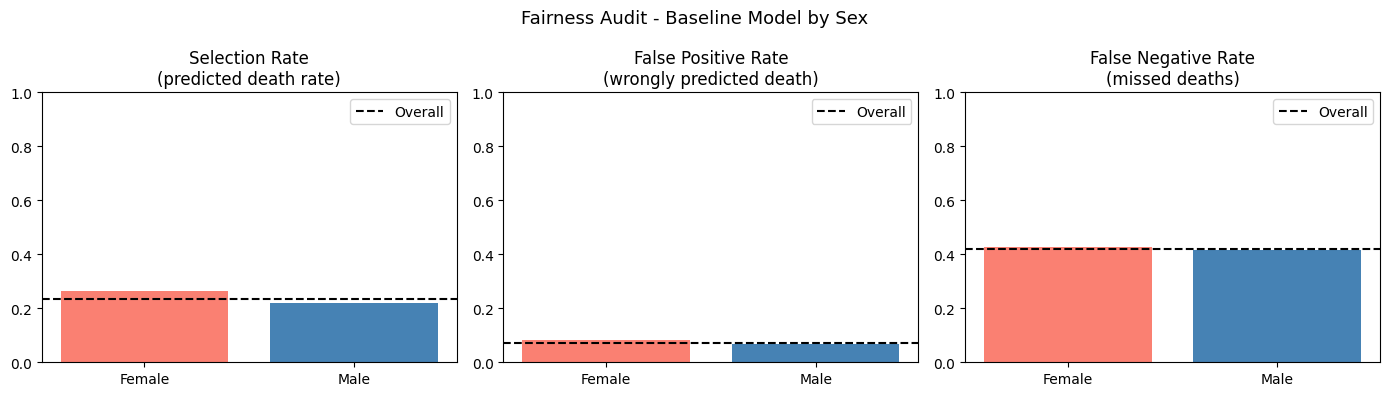

Fairness audit plot saved


In [4]:
# Visualize fairness metrics by sex
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_to_plot = ['selection_rate', 'false_positive_rate', 'false_negative_rate']
titles = ['Selection Rate\n(predicted death rate)', 
          'False Positive Rate\n(wrongly predicted death)', 
          'False Negative Rate\n(missed deaths)']

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    values = metric_frame.by_group[metric]
    values.index = ['Female', 'Male']
    axes[i].bar(values.index, values.values, color=['salmon', 'steelblue'])
    axes[i].set_title(title)
    axes[i].set_ylim(0, 1)
    axes[i].axhline(y=metric_frame.overall[metric], 
                    color='black', linestyle='--', label='Overall')
    axes[i].legend()

plt.suptitle('Fairness Audit - Baseline Model by Sex', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/05_fairness_audit_sex.png')
plt.show()
print("Fairness audit plot saved")

In [5]:
# Demographic parity difference and equalized odds difference
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_test['sex'])
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_test['sex'])

print("Fairness Summary (by Sex):")
print(f"  Demographic Parity Difference: {round(dp_diff, 3)}")
print(f"  Equalized Odds Difference:     {round(eo_diff, 3)}")
print()
print("Interpretation:")
print("  0.0 = perfectly fair")
print("  > 0.1 = meaningful disparity")
print("  > 0.2 = serious disparity")

Fairness Summary (by Sex):
  Demographic Parity Difference: 0.044
  Equalized Odds Difference:     0.014

Interpretation:
  0.0 = perfectly fair
  > 0.1 = meaningful disparity
  > 0.2 = serious disparity


In [6]:
# Repeat fairness audit by age group
metric_frame_age = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test['age_group']
)

print("Metrics by age group:")
print(metric_frame_age.by_group)

Metrics by age group:
           accuracy  selection_rate  false_positive_rate  false_negative_rate
age_group                                                                    
50-60      0.857143        0.142857             0.058824             0.500000
60-70      0.800000        0.400000             0.166667             0.250000
70+        0.750000        0.416667             0.000000             0.375000
<50        0.823529        0.117647             0.071429             0.666667


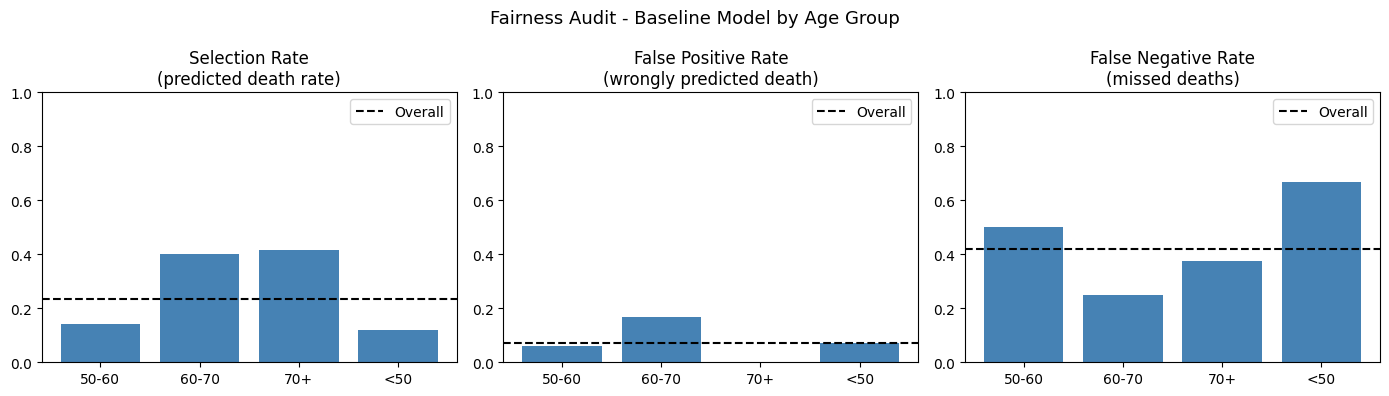

Age group fairness audit saved


In [7]:
# Visualize fairness metrics by age group
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    values = metric_frame_age.by_group[metric]
    axes[i].bar(values.index, values.values, color='steelblue')
    axes[i].set_title(title)
    axes[i].set_ylim(0, 1)
    axes[i].axhline(y=metric_frame_age.overall[metric],
                    color='black', linestyle='--', label='Overall')
    axes[i].legend()

plt.suptitle('Fairness Audit - Baseline Model by Age Group', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/06_fairness_audit_age.png')
plt.show()
print("Age group fairness audit saved")

In [8]:
# Summary table of all disparities
dp_diff_age = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_test['age_group'])
eo_diff_age = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_test['age_group'])

summary = pd.DataFrame({
    'Sensitive Attribute': ['Sex', 'Age Group'],
    'Demographic Parity Difference': [round(dp_diff, 3), round(dp_diff_age, 3)],
    'Equalized Odds Difference': [round(eo_diff, 3), round(eo_diff_age, 3)]
})

print("Fairness Audit Summary:")
print(summary.to_string(index=False))
summary.to_csv('../results/fairness_audit_summary.csv', index=False)
print("\nSummary saved to results/")

Fairness Audit Summary:
Sensitive Attribute  Demographic Parity Difference  Equalized Odds Difference
                Sex                          0.044                      0.014
          Age Group                          0.299                      0.417

Summary saved to results/
